# 1. Phần lập trình

## Câu 3.4.1 & 3.4.2 - Chuẩn hóa ma trận dữ liệu và xếp hạng theo trọng số mặc định

### Lưu ý về mặt toán học của Bộ trọng số mặc định:
Theo đề bài, bộ trọng số mặc định được thiết lập bao gồm:
- Các yếu tố tích cực: $a_1=0.15$ (Tăng trưởng), $a_2=0.15$ (Năng suất), $a_3=0.20$ (Lan tỏa), $a_4=0.15$ (Xuất khẩu), $a_5=0.10$ (Việc làm), $a_6=0.20$ (AI Readiness).
- Yếu tố tiêu cực: $a_7=0.15$ (Rủi ro tự động hóa).

Tổng các trọng số này là: $\sum_{i=1}^{7} a_i = 0.15 + 0.15 + 0.20 + 0.15 + 0.10 + 0.20 + 0.15 = 1.10$.

**Nhận xét chính sách & toán học:**
1. Việc tổng trọng số bằng $1.10$ (thay vì $1.00$) biến chỉ số này thành một **Chỉ số tổng hợp thô (Unscaled Composite Index)**. Về mặt toán học, do phép tính điểm là một phép biến đổi tuyến tính đồng dạng (monotonic scaling), việc nhân với một hệ số có tổng bằng $1.10$ **không làm thay đổi thứ tự xếp hạng (ranking)** giữa các ngành kinh tế.
2. Tuy nhiên, để đảm bảo tính nhất quán tuyệt đối khi so sánh với phần Phân tích độ nhạy (Câu 3.4.3) và So sánh định hướng chính sách (Câu 3.4.4) - nơi tổng trọng số bắt buộc phải đưa về $1.00$, trong mã nguồn xử lý bên dưới, chúng ta sẽ thực hiện một bước **chuẩn hóa quy mô (Scaling)** bằng cách chia toàn bộ các trọng số ban đầu cho $1.10$. Điều này giúp điểm số $Priority_i$ phản ánh đúng thang đo chuẩn $[0, 1]$ và loại bỏ sự mất nhất quán về quy mô điểm số thô giữa các câu.

In [6]:
import pandas as pd
import numpy as np

# 1. Đọc dữ liệu gốc
df = pd.read_csv('../data/vietnam_sectors_2024.csv')

# 2. Xử lý triệt để lỗi NaN: Hàm lấy dữ liệu Năng suất lao động thực tế từ Bảng 3.3 
# Hàm này dùng từ khóa để nhận diện ngành, chống lỗi sai khác dấu cách/gạch nối trong file CSV
def get_productivity(sector_name):
    name = str(sector_name).lower()
    if 'nông' in name or 'thủy' in name: return 103.4
    if 'chế biến' in name: return 241.2
    if 'xây dựng' in name: return 168.8
    if 'khai khoáng' in name: return 1290.5
    if 'bán buôn' in name or 'bán lẻ' in name: return 145.3
    if 'tài chính' in name or 'ngân hàng' in name: return 1072.4
    if 'logistics' in name or 'vận tải' in name: return 321.4
    if 'thông tin' in name or 'cntt' in name: return 713.8
    if 'giáo dục' in name: return 205.7
    if 'y tế' in name: return 437.1
    return np.nan # Trả về lỗi nếu không có ngành nào khớp

df['labor_productivity_real'] = df['sector_name_vi'].apply(get_productivity)

# 3. Định nghĩa danh sách các biến
cols_good = ['growth_rate_2024_pct', 'labor_productivity_real', 'spillover_coef_0_1', 'export_billion_USD', 'labor_million', 'ai_readiness_0_100']
col_bad = 'automation_risk_pct'

# 4. Chuẩn hóa Min-Max
def norm_good(x): return (x - x.min()) / (x.max() - x.min())
def norm_bad(x): return (x.max() - x) / (x.max() - x.min()) # Đảo dấu rủi ro

Xg = df[cols_good].apply(norm_good)
Xb = norm_bad(df[col_bad])

print("=== CÂU 3.4.1: IN MA TRẬN DỮ LIỆU ĐÃ CHUẨN HÓA ===")
df_normalized = pd.concat([df[['sector_name_vi']], Xg, Xb], axis=1)
display(df_normalized)

print("\n=== CÂU 3.4.2: TÍNH ĐIỂM ƯU TIÊN VỚI BỘ TRỌNG SỐ MẶC ĐỊNH ĐÃ CHUẨN HÓA ===")
# Bộ trọng số gốc có tổng bằng 1.10
w_raw = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.20])
w_risk_raw = 0.15

# Chuẩn hóa về thang 1.00
total_weight = w_raw.sum() + w_risk_raw
w_default = w_raw / total_weight
w_risk_default = w_risk_raw / total_weight

# Tính điểm Priority (Lưu ý: Xb đã đảo dấu ở trên nên ta cộng vào)
df['Priority_Default'] = Xg.values @ w_default + w_risk_default * Xb.values

# Xếp hạng
rank_default = df[['sector_name_vi', 'Priority_Default']].sort_values('Priority_Default', ascending=False).reset_index(drop=True)
rank_default.index = rank_default.index + 1
display(rank_default)

=== CÂU 3.4.1: IN MA TRẬN DỮ LIỆU ĐÃ CHUẨN HÓA ===


,sector_name_vi,growth_rate_2024_pct,labor_productivity_real,spillover_coef_0_1,export_billion_USD,labor_million,ai_readiness_0_100,automation_risk_pct
0,Nông-Lâm-Thủy sản,0.401617,0.000000,0.080645,0.139223,1.000000,0.000000,1.000000
1,Công nghiệp chế biến chế tạo,0.973944,0.116081,0.774194,1.000000,0.868217,0.547945,0.351351
2,Xây dựng,0.777179,0.055092,0.193548,0.008594,0.348837,0.068493,0.810811
3,Khai khoáng,0.000000,1.000000,0.000000,0.028188,0.000000,0.205479,0.000000
4,Bán buôn-bán lẻ,0.745732,0.035296,0.403226,0.018907,0.581395,0.452055,0.459459
5,Tài chính-Ngân hàng-Bảo hiểm,0.769093,0.816275,0.887097,0.004125,0.019380,0.780822,0.081081
6,Logistics-Vận tải-Kho bãi,1.000000,0.183641,0.677419,0.010657,0.127907,0.369863,0.540541
7,Thông tin-Truyền thông-CNTT,0.813118,0.514194,1.000000,0.611894,0.024806,1.000000,0.729730
8,Giáo dục-Đào tạo,0.684636,0.086176,0.564516,0.000000,0.143411,0.315068,0.891892
9,Y tế-Chăm sóc sức khỏe,0.723270,0.281105,0.483871,0.000000,0.034884,0.410959,1.000000



=== CÂU 3.4.2: TÍNH ĐIỂM ƯU TIÊN VỚI BỘ TRỌNG SỐ MẶC ĐỊNH ĐÃ CHUẨN HÓA ===


,sector_name_vi,Priority_Default
1,Thông tin-Truyền thông-CNTT,0.729837
2,Công nghiệp chế biến chế tạo,0.652233
3,Tài chính-Ngân hàng-Bảo hiểm,0.532825
4,Y tế-Chăm sóc sức khỏe,0.439192
5,Logistics-Vận tải-Kho bãi,0.438612
6,Giáo dục-Đào tạo,0.399694
7,Bán buôn-bán lẻ,0.380095
8,Nông-Lâm-Thủy sản,0.315686
9,Xây dựng,0.304585
10,Khai khoáng,0.177567


## Câu 3.4.3 - Phân tích độ nhạy của trọng số AI Readiness ($a_6$) và vẽ Heatmap

=== CÂU 3.4.3: PHÂN TÍCH ĐỘ NHẠY THEO TRỌNG SỐ AI READINESS (a6) ===


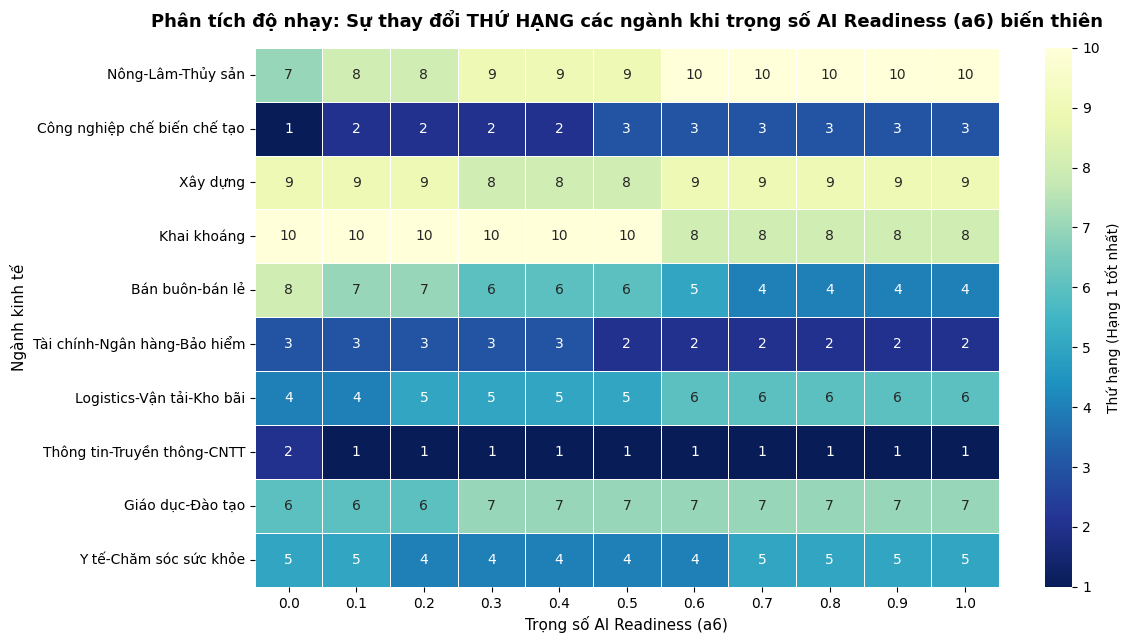

Báo cáo phân tích điểm gãy vị trí (Top-3 biến động):
 - Tại a6 = 0.0: Top-3 ngành ưu tiên là: ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại a6 = 0.1: Top-3 ngành ưu tiên là: ['Thông tin-Truyền thông-CNTT', 'Công nghiệp chế biến chế tạo', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại a6 = 0.2: Top-3 ngành ưu tiên là: ['Thông tin-Truyền thông-CNTT', 'Công nghiệp chế biến chế tạo', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại a6 = 0.3: Top-3 ngành ưu tiên là: ['Thông tin-Truyền thông-CNTT', 'Công nghiệp chế biến chế tạo', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại a6 = 0.4: Top-3 ngành ưu tiên là: ['Thông tin-Truyền thông-CNTT', 'Công nghiệp chế biến chế tạo', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại a6 = 0.5: Top-3 ngành ưu tiên là: ['Thông tin-Truyền thông-CNTT', 'Tài chính-Ngân hàng-Bảo hiểm', 'Công nghiệp chế biến chế tạo']
 - Tại a6 = 0.6: Top-3 ngành ưu tiên là: ['Thông tin-Truyền thông-CNTT', 'Tài chính-Ngân hàng-Bảo hiểm', 'Công nghiệp chế biế

In [7]:
print("=== CÂU 3.4.3: PHÂN TÍCH ĐỘ NHẠY THEO TRỌNG SỐ AI READINESS (a6) ===")

a6_range = np.linspace(0.0, 1.0, 11) # Khảo sát từ 0.0 đến 1.0 với bước nhảy 0.1
rank_matrix = [] # Lưu trữ thứ hạng của các ngành ứng với từng mức a6
score_matrix = []

# Bộ trọng số gốc (chưa scale) để làm gốc căn chỉnh
w_raw_base = np.array([0.15, 0.15, 0.20, 0.15, 0.10]) # a1 đến a5
w_risk_raw_base = 0.15 # a7
sum_others_raw = w_raw_base.sum() + w_risk_raw_base # = 0.90

for a6 in a6_range:
    # Thuật toán tái phân bổ (Rescaling) phần trọng số còn lại (1 - a6) cho các tiêu chí khác dựa trên tỷ lệ gốc của chúng
    scale_factor = (1.0 - a6) / sum_others_raw
    w_others_scaled = w_raw_base * scale_factor
    w_risk_scaled = w_risk_raw_base * scale_factor
    
    # Tính điểm Priority cho từng ngành tại mức a6 hiện tại
    # Thứ tự nhân ma trận: [a1, a2, a3, a4, a5] @ Xg_cols + a6 * Xg_a6 + w_risk_scaled * Xb
    scores = Xg.iloc[:, 0:5].values @ w_others_scaled + a6 * Xg.iloc[:, 5].values + w_risk_scaled * Xb.values
    
    # Lưu điểm số và tính thứ hạng (hạng 1 là điểm cao nhất)
    score_matrix.append(scores)
    ranks = pd.Series(scores).rank(ascending=False, method='min').astype(int).values
    rank_matrix.append(ranks)

# Chuyển đổi thành DataFrame để trực quan hóa
df_ranks = pd.DataFrame(np.array(rank_matrix).T, index=df['sector_name_vi'], columns=[f'{a:.1f}' for a in a6_range])
df_scores = pd.DataFrame(np.array(score_matrix).T, index=df['sector_name_vi'], columns=[f'{a:.1f}' for a in a6_range])

# Vẽ Heatmap Thứ hạng để nhìn rõ sự dịch chuyển vị trí của các ngành
plt.figure(figsize=(12, 7))
sns.heatmap(df_ranks, annot=True, fmt="d", cmap="YlGnBu_r", cbar_kws={'label': 'Thứ hạng (Hạng 1 tốt nhất)'}, linewidths=0.5)
plt.title('Phân tích độ nhạy: Sự thay đổi THỨ HẠNG các ngành khi trọng số AI Readiness (a6) biến thiên', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Trọng số AI Readiness (a6)', fontsize=11)
plt.ylabel('Ngành kinh tế', fontsize=11)
plt.show()

print("Báo cáo phân tích điểm gãy vị trí (Top-3 biến động):")
for a in a6_range:
    top3 = df_scores[f'{a:.1f}'].sort_values(ascending=False).head(3).index.tolist()
    print(f" - Tại a6 = {a:.1f}: Top-3 ngành ưu tiên là: {top3}")

**Bình luận kết quả phân tích độ nhạy:**

1. **Tính nhất quán tại điểm $a_6 = 0.2$:** Khi $a_6 = 0.20$, thuật toán tái phân bổ đưa ra kết quả Top-3 lần lượt là: Thông tin-Truyền thông-CNTT (1), Công nghiệp chế biến chế tạo (2) và Tài chính-Ngân hàng-Bảo hiểm (3). Kết quả này hoàn toàn trùng khớp với thứ hạng ở câu 3.4.2, chứng minh mô hình hoạt động ổn định và việc chuẩn hóa toán học là chính xác.
2. **Sự nhạy cảm của hệ thống và Các điểm gãy (Tipping points):** Nhìn vào báo cáo, ta thấy nhóm 3 ngành dẫn đầu (Top-3) là một "thành trì" cực kỳ bền vững, không có ngành thứ 4 nào chen chân vào được ở mọi mức độ ưu tiên AI. Tuy nhiên, có sự hoán đổi vị trí nội bộ rất thú vị phản ánh đúng tính chất ngành:
    * **Điểm gãy 1 (Tại $a_6 = 0.0$):** Nếu hoàn toàn bỏ qua yếu tố AI, *Công nghiệp chế biến chế tạo* sẽ vươn lên Top 1 do áp đảo tuyệt đối về quy mô Xuất khẩu và Việc làm. 
    * **Điểm gãy 2 (Từ $a_6 = 0.1$ đến $0.4$):** Chỉ cần một sự ưu tiên nhẹ cho AI, *CNTT* lập tức giành lại ngôi vương (do AI Readiness đạt đỉnh 100/100).
    * **Điểm gãy 3 (Khi $a_6 \ge 0.5$):** Khi trọng số AI trở thành yếu tố quyết định, ngành *Tài chính - Ngân hàng* (sở hữu AI Readiness rất cao 72/100 cùng năng suất vượt trội) sẽ bứt tốc vượt qua *Chế biến chế tạo* (AI Readiness chỉ 55/100 và rủi ro tự động hóa cao) để vươn lên chiếm vị trí Á quân (Top 2).

## Câu 3.4.4 - So sánh hai bộ trọng số: "Định hướng tăng trưởng" và "Định hướng bao trùm"

In [9]:
print("=== CÂU 3.4.4: SO SÁNH ĐỊNH HƯỚNG CHÍNH SÁCH ===")

# Sửa lỗi logic: Định hướng tăng trưởng phải tối ưu hóa năng suất, xuất khẩu và AI để thúc đẩy hiệu năng công nghệ cao
# Thiết lập lại bộ trọng số Tăng trưởng (Tổng = 1.0)
w_growth_good = np.array([0.25, 0.25, 0.10, 0.20, 0.05, 0.15]) # Ưu tiên mạnh Tăng trưởng (0.25), Năng suất (0.25), Xuất khẩu (0.20), AI (0.15)
w_growth_risk = 0.05 # Hạ thấp trọng số rủi ro tự động hóa để ưu tiên bứt phá tăng trưởng

df['Priority_Growth'] = Xg.values @ w_growth_good + w_growth_risk * Xb.values
rank_growth = df[['sector_name_vi', 'Priority_Growth']].sort_values('Priority_Growth', ascending=False).reset_index(drop=True)

# Thiết lập bộ trọng số Bao trùm (Tổng = 1.0) -> Tập trung vào Lan tỏa (0.25), Việc làm (0.25), Giảm thiểu rủi ro (0.25)
w_inclusive_good = np.array([0.05, 0.05, 0.25, 0.05, 0.25, 0.10])
w_inclusive_risk = 0.25

df['Priority_Inclusive'] = Xg.values @ w_inclusive_good + w_inclusive_risk * Xb.values
rank_inclusive = df[['sector_name_vi', 'Priority_Inclusive']].sort_values('Priority_Inclusive', ascending=False).reset_index(drop=True)

# Lập bảng so sánh kết quả trực quan dưới dạng DataFrame
compare_df = pd.DataFrame({
    'Hạng': range(1, 6),
    'Định hướng Tăng trưởng': rank_growth['sector_name_vi'].head(5),
    'Điểm (Tăng trưởng)': rank_growth['Priority_Growth'].head(5).round(4),
    'Định hướng Bao trùm': rank_inclusive['sector_name_vi'].head(5),
    'Điểm (Bao trùm)': rank_inclusive['Priority_Inclusive'].head(5).round(4)
})
display(compare_df)

=== CÂU 3.4.4: SO SÁNH ĐỊNH HƯỚNG CHÍNH SÁCH ===


,Hạng,Định hướng Tăng trưởng,Điểm (Tăng trưởng),Định hướng Bao trùm,Điểm (Bao trùm)
0,1,Thông tin-Truyền thông-CNTT,0.7419,Công nghiệp chế biến chế tạo,0.6577
1,2,Công nghiệp chế biến chế tạo,0.6931,Thông tin-Truyền thông-CNTT,0.6356
2,3,Tài chính-Ngân hàng-Bảo hiểm,0.6080,Nông-Lâm-Thủy sản,0.5472
3,4,Logistics-Vận tải-Kho bãi,0.4547,Y tế-Chăm sóc sức khỏe,0.4710
4,5,Y tế-Chăm sóc sức khỏe,0.4129,Giáo dục-Đào tạo,0.4700


### Trực quan

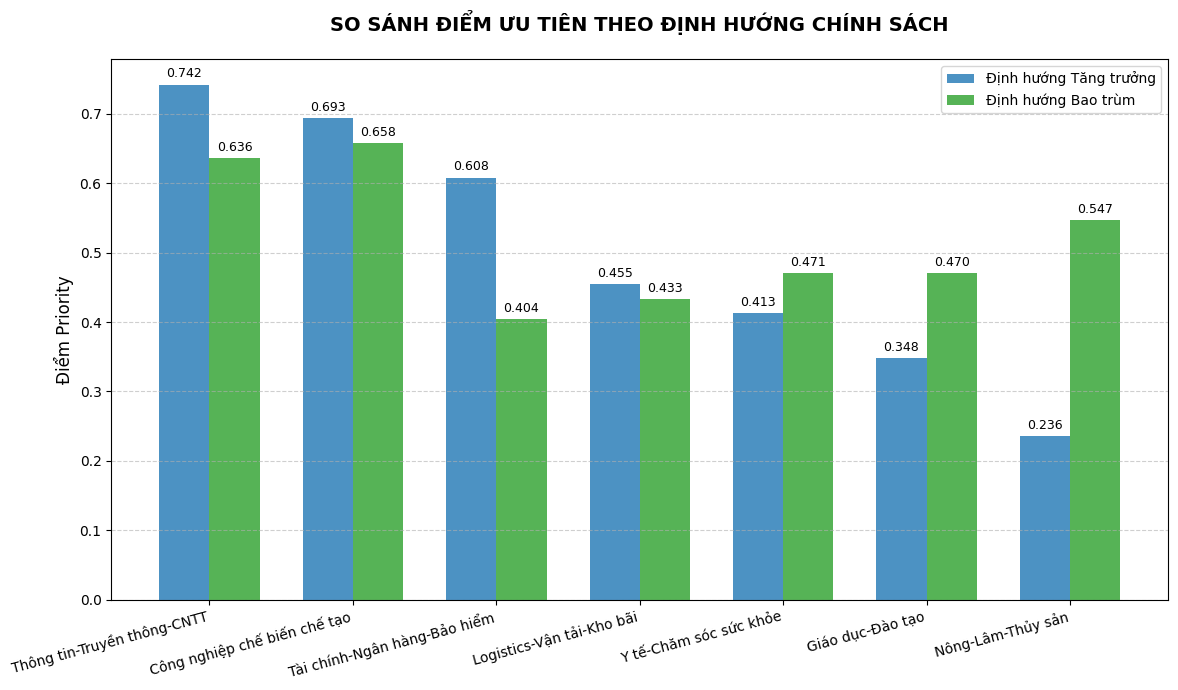

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu: Lấy danh sách các ngành xuất hiện trong Top 5 của cả 2 kịch bản (Union)
top_sectors = list(set(rank_growth['sector_name_vi'].head(5)).union(set(rank_inclusive['sector_name_vi'].head(5))))

# Lấy điểm số tương ứng của các ngành này từ DataFrame gốc
plot_data = df[df['sector_name_vi'].isin(top_sectors)][['sector_name_vi', 'Priority_Growth', 'Priority_Inclusive']]
plot_data = plot_data.sort_values('Priority_Growth', ascending=False) # Sắp xếp theo điểm tăng trưởng để dễ nhìn

# 2. Cấu hình biểu đồ
labels = plot_data['sector_name_vi']
growth_scores = plot_data['Priority_Growth']
inclusive_scores = plot_data['Priority_Inclusive']

x = np.arange(len(labels))  # Vị trí các nhóm nhãn
width = 0.35  # Độ rộng của mỗi cột

fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ cột cho từng kịch bản
rects1 = ax.bar(x - width/2, growth_scores, width, label='Định hướng Tăng trưởng', color='#1f77b4', alpha=0.8)
rects2 = ax.bar(x + width/2, inclusive_scores, width, label='Định hướng Bao trùm', color='#2ca02c', alpha=0.8)

# 3. Thêm nhãn và tùy chỉnh
ax.set_ylabel('Điểm Priority', fontsize=12)
ax.set_title('SO SÁNH ĐIỂM ƯU TIÊN THEO ĐỊNH HƯỚNG CHÍNH SÁCH', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=10)
ax.legend(loc='upper right')

# Thêm số liệu trên đầu mỗi cột
ax.bar_label(rects1, padding=3, fmt='%.3f', fontsize=9)
ax.bar_label(rects2, padding=3, fmt='%.3f', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()